Folder `./notebooks/hpo/gridsearch/results/checkpoints` perlu dihapus jika terdapat perubahan pada dataset atau konfigurasi search space. Jika tidak, maka program akan load hasil dari run sebelumnya. Jadi konfigurasi terbaru hanya akan teraplikasikan pada konfigurasi yang belum atau belum selesai dijalankan.

- Sebelum program dijalankan, buat direktori `./dataset` pada root dir dan upload dataset
- Copy `.env.example` dan rename ke `.env`. Lalu ubah value dari variable `PROJECT_ROOT` menjadi absolute path ke project ini

In [1]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official \
    jinja2 \
    scikit-optimize


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# import sys
# import os
# from pathlib import Path
# from dotenv import load_dotenv, find_dotenv

# # load_dotenv(find_dotenv())
# # project_root = Path(os.environ["PROJECT_ROOT"])
# # print(f"Project root: {project_root}")

# project_name = "codes"

# cwd = os.path.abspath(os.getcwd())
# print(f"Current working directory: {cwd}")
# project_root = cwd.split(project_name)[0] + project_name
# print("Project root:", project_root)

# sys.path.append(os.path.abspath(project_root))

# from utils.prepare_data import prepare_data

import sys
import os

# Add project root (210226) to Python path
sys.path.append(os.path.abspath(".."))

from utils.prepare_data import prepare_data

In [23]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [24]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

In [25]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [ ]:
# dataset_path = os.path.join(project_root, "dataset", "Dataset_TehHijau.csv")
dataset_path = "../dataset/Dataset_TehHijau.csv"
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

quantum_kernel_types = [
    # 'full', 
    'linear', 
    # 'circular', 
    # 'pauli_x', 
    # 'pauli_y', 
    # 'pauli_z'
]
kernel_types = [
    'linear', 
    # 'poly', 
    # 'rbf', 
    # 'sigmoid'
]

In [17]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,...,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
1,90.0,42.0,47.0,133.0,96.0,47.0,551.0,290.0,547.0,371.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
2,89.0,42.0,47.0,133.0,97.0,45.0,553.0,291.0,547.0,369.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
3,89.0,41.0,47.0,133.0,96.0,45.0,552.0,290.0,546.0,370.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
4,90.0,42.0,48.0,132.0,95.0,46.0,552.0,289.0,546.0,371.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
5,90.0,42.0,46.0,132.0,96.0,45.0,552.0,289.0,545.0,370.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
6,89.0,43.0,46.0,133.0,96.0,45.0,552.0,291.0,546.0,369.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
7,90.0,42.0,46.0,132.0,96.0,46.0,551.0,290.0,547.0,370.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
8,90.0,41.0,47.0,132.0,97.0,46.0,550.0,290.0,548.0,370.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
9,90.0,41.0,48.0,132.0,95.0,46.0,551.0,289.0,547.0,371.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8


In [28]:
data.describe()

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Aroma,Taste,Color,Appearance,Dreg,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
count,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,1.040900e+04,1.040900e+04,1.040900e+04,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.0,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000
mean,89.414833,47.600730,47.936209,98.291575,89.182246,51.548756,533.670093,213.738592,531.124604,330.500336,48.387732,39.656701,2.935143,34.888942,3.035383,3.135306,3.071880,89.401187,88.072610,90.838121,0.983066,0.031130,-0.497871,797.282995,51.381383,46.428283,86.377366,12.767992,0.047886,-0.767730,461.091603,48.923492,46.665674,56.401095,3.417439,0.042129,-0.742829,435.501633,98.319587,97.190220,99.975002,0.977440,0.153864,-0.336209,872.003728,89.167083,87.839082,90.566625,0.975194,0.054069,-0.778237,790.103132,52.047207,50.200692,56.931309,2.411880,0.011063,-0.779548,460.377366,533.585382,530.475646,535.648189,1.716062,-0.230519,-0.613955,4754.938419,215.542657,212.039427,231.564223,6.549817,-0.059306,-0.657508,1919.990364,531.039823,529.310693,532.089442,1.000540,-0.031123,-0.890127,4742.842444,330.447166,328.831396,331.640503,0.980595,0.022313,-0.777011,2953.280046,4.077809e+03,48.175252,4.034278e+04,1.274229e+04,-2.069636e-02,-0.

Text(0.5, 1.0, 'Histogram for the Kategori')

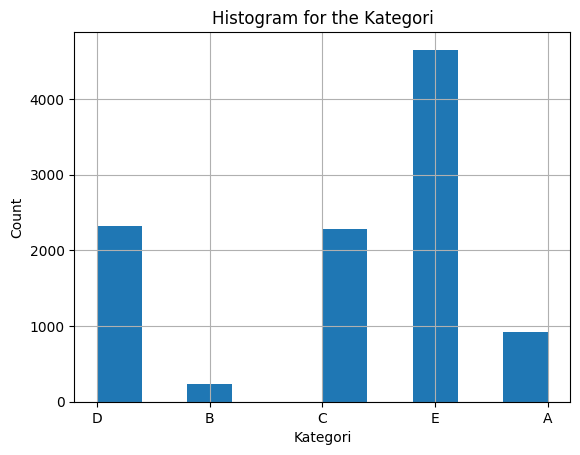

In [29]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

In [10]:
X = data[feature_cols]
y = data[target_cols]

print(X.shape, y.shape)

(10409, 12) (10409,)


In [11]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [12]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

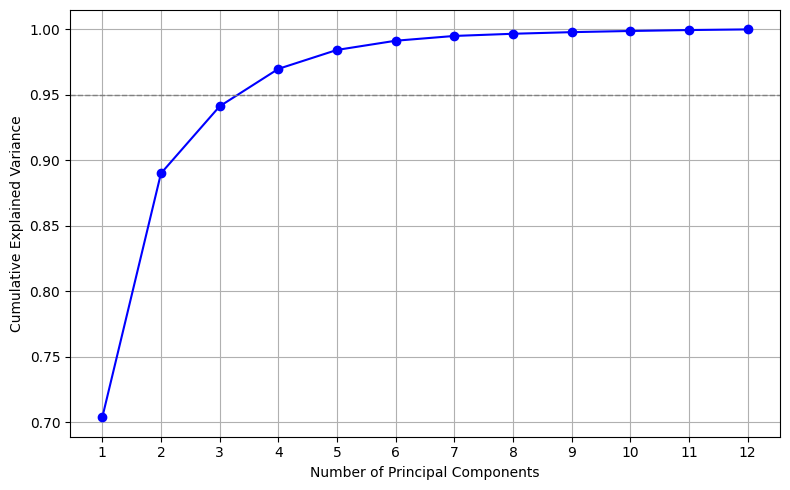

Optimal number of components to retain 95% variance: 4


In [13]:
n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.95)

In [14]:
import time
from pathlib import Path
from datetime import datetime

all_best = []  # collects best_result from every model
_iter_t0 = None

# Logger setup
log_dir = Path("./results/logs/fsk")
log_dir.mkdir(parents=True, exist_ok=True)

_current_log_path = None

def setup_logger(name):
  """Panggil di awal tiap section. name contoh: 'svc_linear', 'xgb_gbtree'."""
  global _current_log_path
  _current_log_path = log_dir / f"quantum_{name}_hpo.log"
  # truncate file kalau sudah ada, biar tiap run fresh
  _current_log_path.write_text("")
  log(f"📝 Log: {_current_log_path}")
  log(f"🕒 Started: {datetime.now().isoformat(timespec='seconds')}")

def log(msg=""):
  """Print ke console dan append ke file log section aktif."""
  print(msg)
  if _current_log_path is not None:
    with open(_current_log_path, "a", encoding="utf-8") as f:
      f.write(str(msg) + "\n")


In [15]:
import pickle
from pathlib import Path

# Checkpoint dir — sama strukturnya kayak log_dir tapi pakai .pkl
ckpt_dir = Path("./results/checkpoints/all")  # ganti path sesuai notebook
ckpt_dir.mkdir(parents=True, exist_ok=True)

def load_checkpoint(name):
    """Load checkpoint kalau ada, return dict kosong kalau belum ada."""
    ckpt_path = ckpt_dir / f"quantum_{name}_hpo.pkl"
    if ckpt_path.exists():
        with open(ckpt_path, "rb") as f:
            data = pickle.load(f)
        log(f"♻️  Resumed checkpoint: {ckpt_path} ({len(data['done_configs'])} configs done)")
        return data, ckpt_path
    return {"done_configs": {}, "results": [], "best_result": None, "best_score": -np.inf}, ckpt_path

def save_checkpoint(ckpt_path, data):
    """Save progress atomically (tulis ke .tmp dulu, lalu rename)."""
    tmp = ckpt_path.with_suffix(".pkl.tmp")
    with open(tmp, "wb") as f:
        pickle.dump(data, f)
    tmp.replace(ckpt_path)  # atomic on most filesystems

# Quantum Global Configuration

In [16]:
mode = 'fsk'

# Full

In [17]:
QKERNEL='full'

## 1. QSVC

In [18]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [0.1, 1, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [19]:
setup_logger("qsvc_full")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qsvc import QSVCWrapper
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qsvc_full")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', QSVCWrapper(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_state=42, 
        decision_function_shape='ovr',
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\quantum\fsk\qsvc_full.log
🕒 Started: 2026-05-26T20:45:16


🔬 Search space: 3 C × 2 lambda_ × 2 n_measurements =  12 configs × 5 folds = 60 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3
♻️  Resumed checkpoint: results\checkpoints\gs\quantum\all\qsvc_full.pkl (12 configs done)

  ⏭️  [1/12] C=0.1 | lambda_=0.1 | n_measurements=256  (skipped, already done)

  ⏭️  [2/12] C=0.1 | lambda_=0.1 | n_measurements=1024  (skipped, already done)

  ⏭️  [3/12] C=0.1 | lambda_=5 | n_measurements=256  (skipped, already done)

  ⏭️  [4/12] C=0.1 | lambda_=5 | n_measurements=1024  (skipped, already done)

  ⏭️  [5/12] C=1 | lambda_=0.1 | n_measurements=256  (skipped, already done)

  ⏭️  [6/12] C=1 | lambda_=0.1 | n_measurements=1024  (skipped, already done)

  ⏭️  [7/12] C=1 | lambda_=5 | n_measurements=256  (skipped, already done)

  ⏭️  [8/12] C=1 | lambda_=5 | n_measurements=1024  (skipped, already done)

  ⏭️  [9/12] C=10 | lambda_=0.1 | n_measurements=256  (skipped, already done)

  ⏭️  [10/12] C=10 | lambda_=0.1 | n_measurements=1024  (skippe

In [20]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qsvc_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/qsvc_full.csv


In [21]:
# ── Collect best result ──
best_result['model'] = f"QSVC ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QSVC ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [QSVC (full)] recorded | Exec. time: 49.6s


## 2. QXGB (Hybrid Quantum XGBoost)

### 2.1 GBTree

In [22]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [23]:
setup_logger("qxgb_gbtree_full")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_gbtree_full")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='gbtree',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\quantum\fsk\qxgb_gbtree_full.log
🕒 Started: 2026-05-26T20:45:18
🔬 Search space: 2 n_estimators × 2 learning_rate × 2 max_depth × 2 lambda_ × 2 n_measurements =  32 configs × 5 folds = 160 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3
♻️  Resumed checkpoint: results\checkpoints\gs\quantum\all\qxgb_gbtree_full.pkl (4 configs done)

  ⏭️  [1/32] n_estimators=100 | learning_rate=0.01 | max_depth=4 | lambda_=0.1 | n_measurements=256  (skipped, already done)

  ⏭️  [2/32] n_estimators=100 | learning_rate=0.01 | max_depth=4 | lambda_=0.1 | n_measurements=1024  (skipped, already done)

  ⏭️  [3/32] n_estimators=100 | learning_rate=0.01 | max_depth=4 | lambda_=5 | n_measurements=256  (skipped, already done)

  ⏭️  [4/32] n_estimators=100 | learning_rate=0.01 | max_depth=4 | lambda_=5 | n_measurements=1024  (skipped, already done)

  ▶ [5/32] n_estimators=100 | learning_rate=0.01 | max_depth=10 | lambda_=0.1 | n_measurements=256


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_gbtree_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/qxgb_gbtree_full.csv


In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB GBTree ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB GBTree ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [QXGB GBTree (full)] recorded | Exec. time: 45.3s


### 2.2 Dart

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  'rate_drop': [0.1, 0.5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qxgb_dart_full")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_dart_full")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='dart',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\quantum\all\fsk\qxgb_dart_full.log
🕒 Started: 2026-05-25T02:05:27
🔬 Search space: 2 n_estimators × 2 learning_rate × 2 max_depth × 2 rate_drop × 2 lambda_ × 1 n_measurements =  32 configs × 5 folds = 160 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/32] n_estimators=100 | learning_rate=0.01 | max_depth=4 | rate_drop=0.1 | lambda_=0.1 | n_measurements=None
    F1 → Acc=0.4381 | Prec=0.1919 | Rec=0.4381 | F1=0.2669 | AUROC=0.9270 | PRAUC=0.8511
    F2 → Acc=0.4519 | Prec=0.2042 | Rec=0.4519 | F1=0.2813 | AUROC=0.9145 | PRAUC=0.8396
    F3 → Acc=0.4519 | Prec=0.2042 | Rec=0.4519 | F1=0.2813 | AUROC=0.9759 | PRAUC=0.9538
    F4 → Acc=0.4519 | Prec=0.2042 | Rec=0.4519 | F1=0.2813 | AUROC=0.9476 | PRAUC=0.8991
    F5 → Acc=0.4423 | Prec=0.1956 | Rec=0.4423 | F1=0.2713 | AUROC=0.9375 | PRAUC=0.8828
  ✅  Acc:0.4472±0.0059 | Precision:0.2001±0.0053  |Recall:0.4472±0.0059 |F1:0.2764±0.0061 | AUROC:0.9405±0.0208 | PRAUC:0.8853±0.0404 | MCC:0.0000 | Compo

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_dart_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/qxgb_dart_full.csv


In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB Dart ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB Dart ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [QXGB Dart (full)] recorded | Exec. time: 370.1s


## 3. QCat (Hybrid Quantum Catboost)

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'iterations': [100, 500],
  'depth': [4, 10],
  'learning_rate': [0.01, 0.1],
  'l2_leaf_reg': [1, 5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qcat_full")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qcat import QCAT
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qcat_full")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qcat', QCAT(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_seed=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)  # Normalize probabilities

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\quantum\all\fsk\qcat_full.log
🕒 Started: 2026-05-25T03:45:22
🔬 Search space: 2 iterations × 2 depth × 2 learning_rate × 2 l2_leaf_reg × 2 lambda_ × 1 n_measurements =  32 configs × 5 folds = 160 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/32] iterations=100 | depth=4 | learning_rate=0.01 | l2_leaf_reg=1 | lambda_=0.1 | n_measurements=None
    F1 → Acc=0.6857 | Prec=0.7027 | Rec=0.6857 | F1=0.6587 | AUROC=0.8903 | PRAUC=0.7862
    F2 → Acc=0.7308 | Prec=0.7394 | Rec=0.7308 | F1=0.7016 | AUROC=0.9118 | PRAUC=0.8031
    F3 → Acc=0.7692 | Prec=0.7723 | Rec=0.7692 | F1=0.7469 | AUROC=0.9582 | PRAUC=0.8948
    F4 → Acc=0.7692 | Prec=0.7600 | Rec=0.7692 | F1=0.7557 | AUROC=0.9251 | PRAUC=0.8575
    F5 → Acc=0.7404 | Prec=0.7532 | Rec=0.7404 | F1=0.7155 | AUROC=0.9399 | PRAUC=0.8630
  ✅  Acc:0.7391±0.0308 | Precision:0.7455±0.0239  |Recall:0.7391±0.0308 |F1:0.7157±0.0347 | AUROC:0.9251±0.0232 | PRAUC:0.8409±0.0402 | MCC:0.6165 | Composite:0.8350

  

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qcat_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/qcat_full.csv


In [ ]:
# ── Collect best result ──
best_result['model'] = f"QCat ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QCat ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [QCat (full)] recorded | Exec. time: 281.2s


# Linear

In [ ]:
QKERNEL='linear'

## 1. QSVC

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [0.1, 1, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qsvc_linear")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qsvc import QSVCWrapper
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qsvc_linear")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', QSVCWrapper(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_state=42, 
        decision_function_shape='ovr',
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\quantum\all\fsk\qsvc_linear.log
🕒 Started: 2026-05-25T04:47:13
🔬 Search space: 3 C × 2 lambda_ × 1 n_measurements =  6 configs × 5 folds = 30 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/6] C=0.1 | lambda_=0.1 | n_measurements=None
    F1 → Acc=0.5429 | Prec=0.6268 | Rec=0.5429 | F1=0.4432 | AUROC=0.8826 | PRAUC=0.7511
    F2 → Acc=0.5673 | Prec=0.5574 | Rec=0.5673 | F1=0.4856 | AUROC=0.8158 | PRAUC=0.6515
    F3 → Acc=0.5481 | Prec=0.6330 | Rec=0.5481 | F1=0.4411 | AUROC=0.9066 | PRAUC=0.8149
    F4 → Acc=0.5385 | Prec=0.5346 | Rec=0.5385 | F1=0.4396 | AUROC=0.8560 | PRAUC=0.7378
    F5 → Acc=0.5096 | Prec=0.4309 | Rec=0.5096 | F1=0.3878 | AUROC=0.8978 | PRAUC=0.7933
  ✅  Acc:0.5413±0.0186 | Precision:0.5565±0.0736  |Recall:0.5413±0.0186 |F1:0.4395±0.0310 | AUROC:0.8718±0.0328 | PRAUC:0.7497±0.0565 | MCC:0.3121 | Composite:0.7209

  ▶ [2/6] C=0.1 | lambda_=5 | n_measurements=None
    F1 → Acc=0.4381 | Prec=0.1919 | Rec=0.4381 | F1=0.2669 | A

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qsvc_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/qsvc_linear.csv


In [ ]:
# ── Collect best result ──
best_result['model'] = f"QSVC ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QSVC ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [QSVC (linear)] recorded | Exec. time: 16.5s


## 2. QXGB (Hybrid Quantum XGBoost)

### 2.1 GBTree

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qxgb_gbtree_linear")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_gbtree_linear")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='gbtree',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\quantum\all\fsk\qxgb_gbtree_linear.log
🕒 Started: 2026-05-25T04:48:52
🔬 Search space: 2 n_estimators × 2 learning_rate × 2 max_depth × 2 lambda_ × 1 n_measurements =  16 configs × 5 folds = 80 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/16] n_estimators=100 | learning_rate=0.01 | max_depth=4 | lambda_=0.1 | n_measurements=None
    F1 → Acc=0.6857 | Prec=0.7377 | Rec=0.6857 | F1=0.6592 | AUROC=0.9315 | PRAUC=0.8648
    F2 → Acc=0.7596 | Prec=0.7667 | Rec=0.7596 | F1=0.7390 | AUROC=0.9194 | PRAUC=0.8241
    F3 → Acc=0.8462 | Prec=0.8591 | Rec=0.8462 | F1=0.8321 | AUROC=0.9825 | PRAUC=0.9591
    F4 → Acc=0.7500 | Prec=0.7735 | Rec=0.7500 | F1=0.7318 | AUROC=0.9551 | PRAUC=0.9151
    F5 → Acc=0.7404 | Prec=0.7962 | Rec=0.7404 | F1=0.7160 | AUROC=0.9613 | PRAUC=0.9233
  ✅  Acc:0.7564±0.0517 | Precision:0.7866±0.0408  |Recall:0.7564±0.0517 |F1:0.7356±0.0558 | AUROC:0.9500±0.0223 | PRAUC:0.8973±0.0474 | MCC:0.6488 | Composite:0.8679

  ▶ [2/16] n_e

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_gbtree_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/qxgb_gbtree_linear.csv


In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB GBTree ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB GBTree ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [QXGB GBTree (linear)] recorded | Exec. time: 48.6s


### 2.2 Dart

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  'rate_drop': [0.1, 0.5],
  'skip_drop': [0.1, 0.5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qxgb_dart_linear")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_dart_linear")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='dart',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\quantum\all\fsk\qxgb_dart_linear.log
🕒 Started: 2026-05-25T05:01:49
🔬 Search space: 2 n_estimators × 2 learning_rate × 2 max_depth × 2 rate_drop × 2 skip_drop × 2 lambda_ × 1 n_measurements =  64 configs × 5 folds = 320 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/64] n_estimators=100 | learning_rate=0.01 | max_depth=4 | rate_drop=0.1 | skip_drop=0.1 | lambda_=0.1 | n_measurements=None
    F1 → Acc=0.4381 | Prec=0.1919 | Rec=0.4381 | F1=0.2669 | AUROC=0.9107 | PRAUC=0.8192
    F2 → Acc=0.4519 | Prec=0.2042 | Rec=0.4519 | F1=0.2813 | AUROC=0.8834 | PRAUC=0.7892
    F3 → Acc=0.4519 | Prec=0.2042 | Rec=0.4519 | F1=0.2813 | AUROC=0.9756 | PRAUC=0.9454
    F4 → Acc=0.4519 | Prec=0.2042 | Rec=0.4519 | F1=0.2813 | AUROC=0.9413 | PRAUC=0.8840
    F5 → Acc=0.4423 | Prec=0.1956 | Rec=0.4423 | F1=0.2713 | AUROC=0.9528 | PRAUC=0.8999
  ✅  Acc:0.4472±0.0059 | Precision:0.2001±0.0053  |Recall:0.4472±0.0059 |F1:0.2764±0.0061 | AUROC:0.9327±0.0323 | PRAUC:0.

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_dart_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB Dart ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB Dart ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

## 3. QCat (Hybrid Quantum Catboost)

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'iterations': [100, 500],
  'depth': [4, 10],
  'learning_rate': [0.01, 0.1],
  'l2_leaf_reg': [1, 5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qcat_linear")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qcat import QCAT
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qcat_linear")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qcat', QCAT(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_seed=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)  # Normalize probabilities

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qcat_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QCat ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QCat ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

# Circular

In [ ]:
QKERNEL='circular'

## 1. QSVC

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [0.1, 1, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qsvc_circular")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qsvc import QSVCWrapper
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qsvc_circular")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', QSVCWrapper(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_state=42, 
        decision_function_shape='ovr',
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qsvc_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QSVC ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QSVC ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

## 2. QXGB (Hybrid Quantum XGBoost)

### 2.1 GBTree

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qxgb_gbtree_circular")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_gbtree_circular")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='gbtree',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_gbtree_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB GBTree ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB GBTree ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

### 2.2 Dart

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  'rate_drop': [0.1, 0.5],
  'skip_drop': [0.1, 0.5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qxgb_dart_circular")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_dart_circular")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='dart',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_dart_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB Dart ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB Dart ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

## 3. QCat (Hybrid Quantum Catboost)

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'iterations': [100, 500],
  'depth': [4, 10],
  'learning_rate': [0.01, 0.1],
  'l2_leaf_reg': [1, 5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qcat_circular")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qcat import QCAT
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qcat_circular")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qcat', QCAT(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_seed=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)  # Normalize probabilities

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qcat_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QCat ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QCat ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

# Pauli X

In [ ]:
QKERNEL='pauli_x'

## 1. QSVC

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [0.1, 1, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qsvc_paulix")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qsvc import QSVCWrapper
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qsvc_paulix")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', QSVCWrapper(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_state=42, 
        decision_function_shape='ovr',
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qsvc_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QSVC ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QSVC ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

## 2. QXGB (Hybrid Quantum XGBoost)

### 2.1 GBTree

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qxgb_gbtree_paulix")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_gbtree_paulix")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='gbtree',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_gbtree_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB GBTree ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB GBTree ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

### 2.2 Dart

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  'rate_drop': [0.1, 0.5],
  'skip_drop': [0.1, 0.5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qxgb_dart_paulix")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_dart_paulix")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='dart',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_dart_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB Dart ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB Dart ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

## 3. QCat (Hybrid Quantum Catboost)

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'iterations': [100, 500],
  'depth': [4, 10],
  'learning_rate': [0.01, 0.1],
  'l2_leaf_reg': [1, 5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qcat_paulix")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qcat import QCAT
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qcat_paulix")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qcat', QCAT(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_seed=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)  # Normalize probabilities

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qcat_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QCat ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QCat ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

# Pauli Y

In [ ]:
QKERNEL='pauli_y'

## 1. QSVC

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [0.1, 1, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qsvc_pauliy")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qsvc import QSVCWrapper
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qsvc_pauliy")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', QSVCWrapper(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_state=42, 
        decision_function_shape='ovr',
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qsvc_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QSVC ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QSVC ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

## 2. QXGB (Hybrid Quantum XGBoost)

### 2.1 GBTree

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qxgb_gbtree_pauliy")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_gbtree_pauliy")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='gbtree',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_gbtree_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB GBTree ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB GBTree ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

### 2.2 Dart

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  'rate_drop': [0.1, 0.5],
  'skip_drop': [0.1, 0.5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qxgb_dart_pauliy")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_dart_pauliy")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='dart',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_dart_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB Dart ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB Dart ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

## 3. QCat (Hybrid Quantum Catboost)

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'iterations': [100, 500],
  'depth': [4, 10],
  'learning_rate': [0.01, 0.1],
  'l2_leaf_reg': [1, 5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qcat_pauliy")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qcat import QCAT
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qcat_pauliy")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qcat', QCAT(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_seed=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)  # Normalize probabilities

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qcat_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QCat ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QCat ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

# Pauli Z

In [ ]:
QKERNEL='pauli_z'

## 1. QSVC

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [0.1, 1, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qsvc_pauliz")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qsvc import QSVCWrapper
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qsvc_pauliz")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', QSVCWrapper(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_state=42, 
        decision_function_shape='ovr',
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qsvc_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QSVC ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QSVC ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

## 2. QXGB (Hybrid Quantum XGBoost)

### 2.1 GBTree

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qxgb_gbtree_pauliz")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_gbtree_pauliz")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='gbtree',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_gbtree_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB GBTree ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB GBTree ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

### 2.2 Dart

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  'rate_drop': [0.1, 0.5],
  'skip_drop': [0.1, 0.5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qxgb_dart_pauliz")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qxgb import QXGB
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qxgb_dart_pauliz")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qxgb', QXGB(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        booster='dart',
        random_state=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qxgb_dart_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QXGB Dart ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QXGB Dart ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

## 3. QCat (Hybrid Quantum Catboost)

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'iterations': [100, 500],
  'depth': [4, 10],
  'learning_rate': [0.01, 0.1],
  'l2_leaf_reg': [1, 5],

  # quantum params
  'lambda_': [0.1, 5],
  'n_measurements': [256, 1024],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("qcat_pauliz")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qcat import QCAT
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

ckpt, ckpt_path = load_checkpoint("qcat_pauliz")
done_configs = ckpt["done_configs"]   # {tag: {agg_metrics...}}
results = ckpt["results"]              # list of per-fold dicts
best_result = ckpt["best_result"]
best_score = ckpt["best_score"]

# best_score = -np.inf
# best_result = None
# results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())

  if tag in done_configs:
    log(f"\n  ⏭️  [{i+1}/{total_configs}] {tag}  (skipped, already done)")
    continue

  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # n_measurement dipakai kalau mode != 'fsk'
    
    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('qcat', QCAT(
        # quantum
        kernel=QKERNEL, 
        mode=mode, 
        n_qubits=n_optimal,
        n_features=n_optimal,

        # classical
        random_seed=42,
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)  # Normalize probabilities

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    #  
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

  done_configs[tag] = {"composite": composite, "params": params}
  save_checkpoint(ckpt_path, {
      "done_configs": done_configs,
      "results": results,
      "best_result": best_result,
      "best_score": best_score,
  })

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + f"qcat_{QKERNEL}_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

In [ ]:
# ── Collect best result ──
best_result['model'] = f"QCat ({QKERNEL})"
all_best.append(dict(best_result))
log(f"✅ [QCat ({QKERNEL})] recorded | Exec. time: {best_result['execution_time']:.1f}s")

---
# 📊 Tabel Evaluasi Akhir

In [ ]:
# ════════════════════════════════════════════════════════════
# 📊 TABEL EVALUASI AKHIR – Quantum Models
# ════════════════════════════════════════════════════════════
import pandas as pd

KERNEL_ORDER = {'full': 0, 'linear': 1, 'circular': 2,
                'pauli_x': 3, 'pauli_y': 4, 'pauli_z': 5}

def build_eval_table(all_best):
    rows = []
    for r in all_best:
        params_str = ' | '.join(f'{k}={v}' for k, v in r.get('params', {}).items())
        rows.append({
            'Model'          : r['model'],
            'Accuracy'       : r['acc'],
            'Precision'      : r['prec'],
            'Recall'         : r['rec'],
            'F1-Score'       : r['f1'],
            'ROC-AUC'        : r['roc'],
            'PR-AUC'         : r['pra'],
            'Exec. Time (s)' : round(r['execution_time'], 2) if 'execution_time' in r else 'N/A',
            'Best Params'    : params_str,
        })
    df = pd.DataFrame(rows)
    def _kord(m):
        for k, v in KERNEL_ORDER.items():
            if k in m.lower(): return v
        return 99
    df['_kord'] = df['Model'].apply(_kord)
    df = df.sort_values(['_kord', 'ROC-AUC'], ascending=[True, False])
    df = df.drop(columns=['_kord']).reset_index(drop=True)
    df.index += 1
    return df

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

eval_df = build_eval_table(all_best)
display(eval_df)

In [ ]:
import os
os.makedirs('./results', exist_ok=True)
eval_df.to_csv('./results/eval_quantum_final_hpo.csv', index=True)
print('✅ Saved: ./results/eval_quantum_final_hpo.csv')